## House Price Category Prediction Using Machine Learning Classification Algorithms

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Import classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### Loading the dataset

In [2]:
# Load the training dataset
df = pd.read_csv("train.csv")

# Display first five rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

#### Checking the target column

In [4]:
# Check SalePrice statistics
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

#### Creating price categories

In [5]:
# Create three price categories: Low, Medium, High
df["PriceCategory"] = pd.qcut(
    df["SalePrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check category counts
df["PriceCategory"].value_counts()

PriceCategory
Medium    490
Low       487
High      483
Name: count, dtype: int64

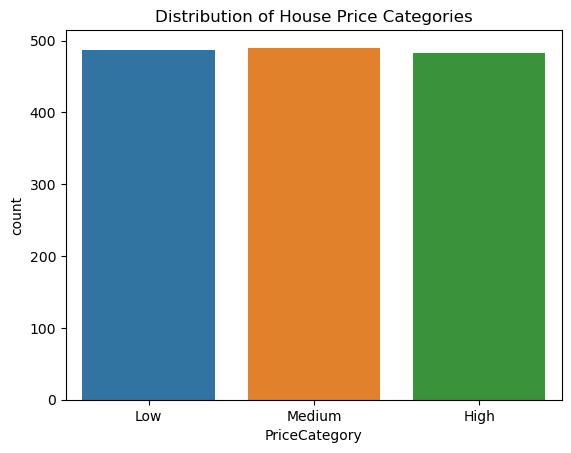

In [6]:
# checking visually
sns.countplot(x="PriceCategory", data=df)
plt.title("Distribution of House Price Categories")
plt.show()

#### Droping unnecessaty columns

In [7]:
# Drop original target and ID column
X = df.drop(["SalePrice", "PriceCategory", "Id"], axis=1)

# New classification target
y = df["PriceCategory"]

#### Handling missing values

In [8]:
# Separate numerical and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 36
Number of categorical columns: 43


In [9]:
## filling missing values

# Fill missing numerical values with median
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [10]:
# check for missing values
X.isnull().sum().sum()

0

#### Encode categorical variables

In [11]:
# Convert categorical columns into numeric dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [12]:
X_encoded.shape

(1460, 244)

#### Spliting train and test data

In [13]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1168, 244)
Testing data shape: (292, 244)


#### Scaling the data

In [14]:
# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Training 5 classification algorithms

We will use:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. K-Nearest Neighbors

In [15]:
# Define the classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

#### Evaluating the models

In [16]:
# Store results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.767123,0.771310,0.767123,0.768113
1,Decision Tree,0.736301,0.737834,0.736301,0.736520
2,Random Forest,0.811644,0.809002,0.811644,0.809153
3,Support Vector Machine,0.794521,0.793227,0.794521,0.793781
4,K-Nearest Neighbors,0.726027,0.720097,0.726027,0.719533


#### Sorting models by F1-score

In [17]:
# Sort by F1 Score
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.811644,0.809002,0.811644,0.809153
3,Support Vector Machine,0.794521,0.793227,0.794521,0.793781
0,Logistic Regression,0.767123,0.771310,0.767123,0.768113
1,Decision Tree,0.736301,0.737834,0.736301,0.736520
4,K-Nearest Neighbors,0.726027,0.720097,0.726027,0.719533


#### Visualising model performance

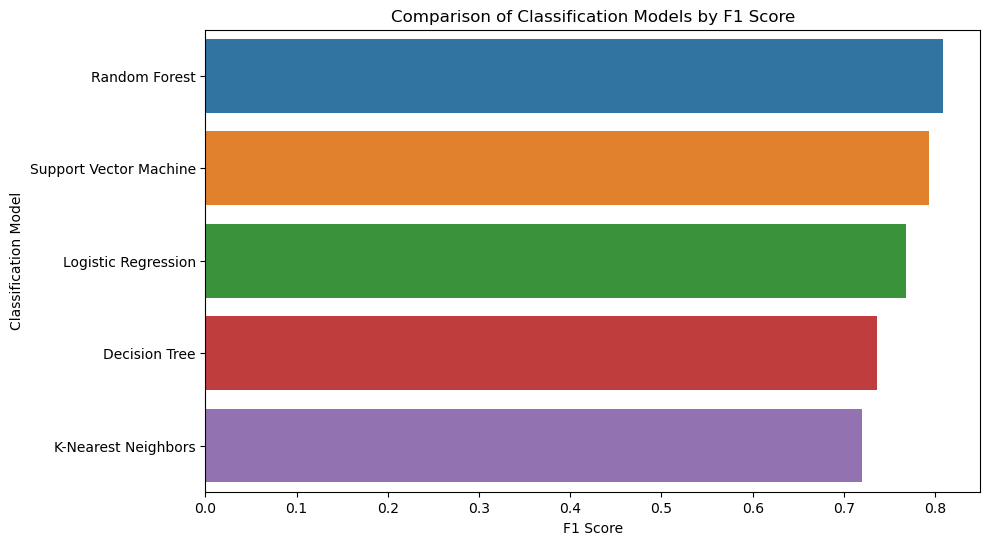

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x="F1 Score", y="Model", data=results_df.sort_values(by="F1 Score", ascending=False))
plt.title("Comparison of Classification Models by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Classification Model")
plt.show()

#### Printing classification report for each model

In [20]:
for model_name, model in models.items():
    print("\n==============================")
    print(model_name)
    print("==============================")
    
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

        High       0.84      0.87      0.85        97
         Low       0.83      0.74      0.78        97
      Medium       0.65      0.69      0.67        98

    accuracy                           0.77       292
   macro avg       0.77      0.77      0.77       292
weighted avg       0.77      0.77      0.77       292


Decision Tree
              precision    recall  f1-score   support

        High       0.77      0.81      0.79        97
         Low       0.80      0.74      0.77        97
      Medium       0.64      0.65      0.65        98

    accuracy                           0.74       292
   macro avg       0.74      0.74      0.74       292
weighted avg       0.74      0.74      0.74       292


Random Forest
              precision    recall  f1-score   support

        High       0.84      0.93      0.88        97
         Low       0.84      0.82      0.83        97
      Medium       0.74 

#### confusion matrix of all the models

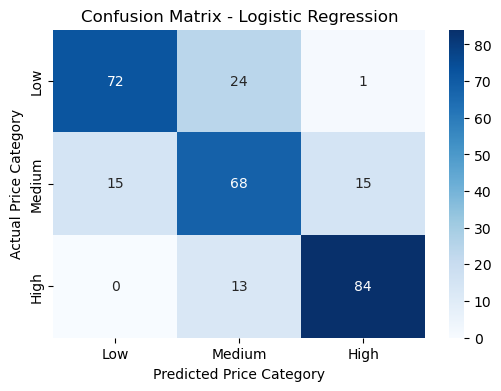

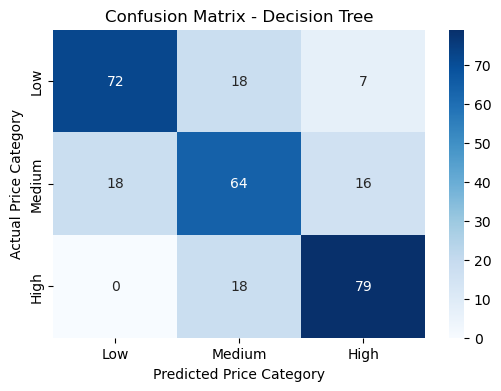

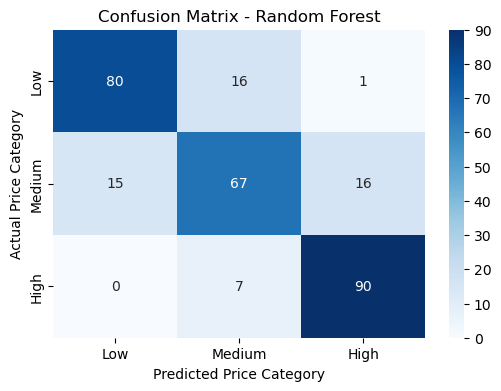

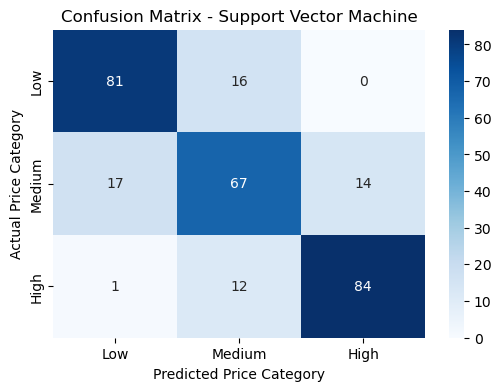

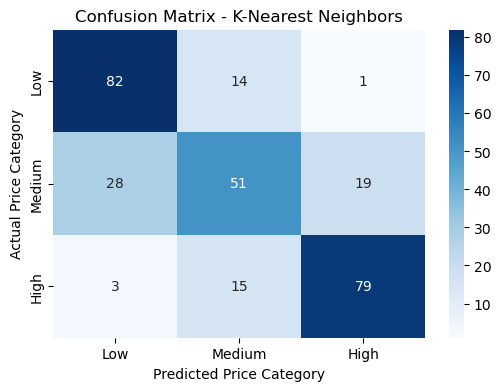

In [21]:
# Confusion matrices for all models

for model_name, model in models.items():
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict test data
    y_pred = model.predict(X_test_scaled)
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Price Category")
    plt.ylabel("Actual Price Category")
    plt.show()

#### Feature importance graph for Random Forest

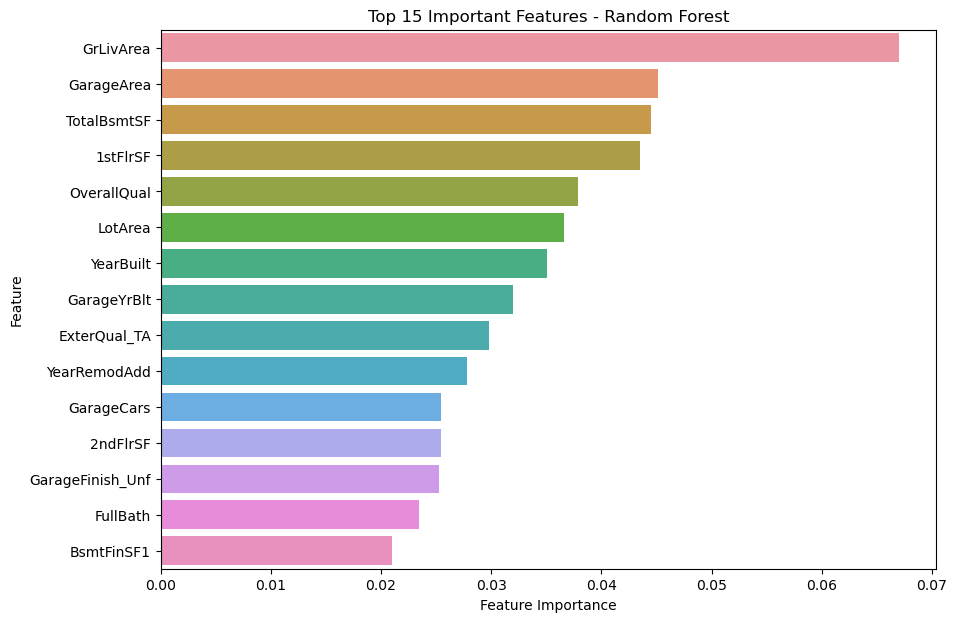

In [23]:
# Train Random Forest again
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

# Select top 15 features
top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

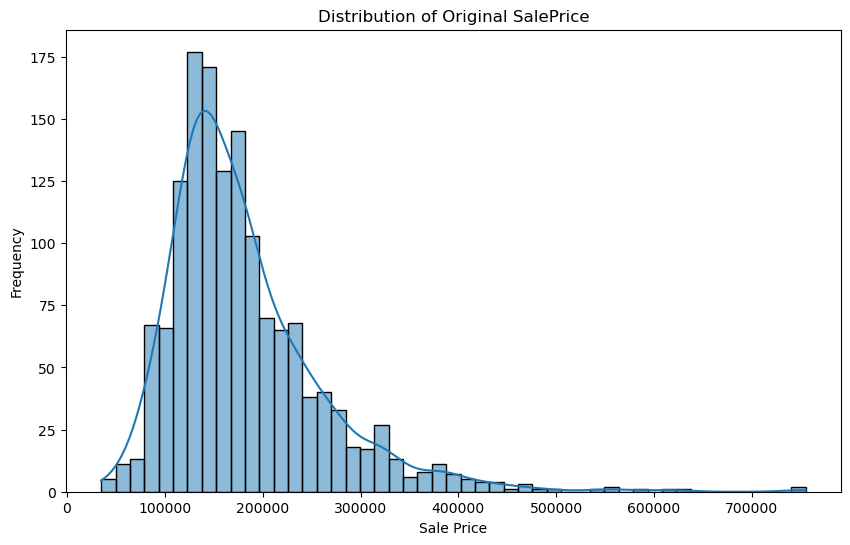

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Original SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

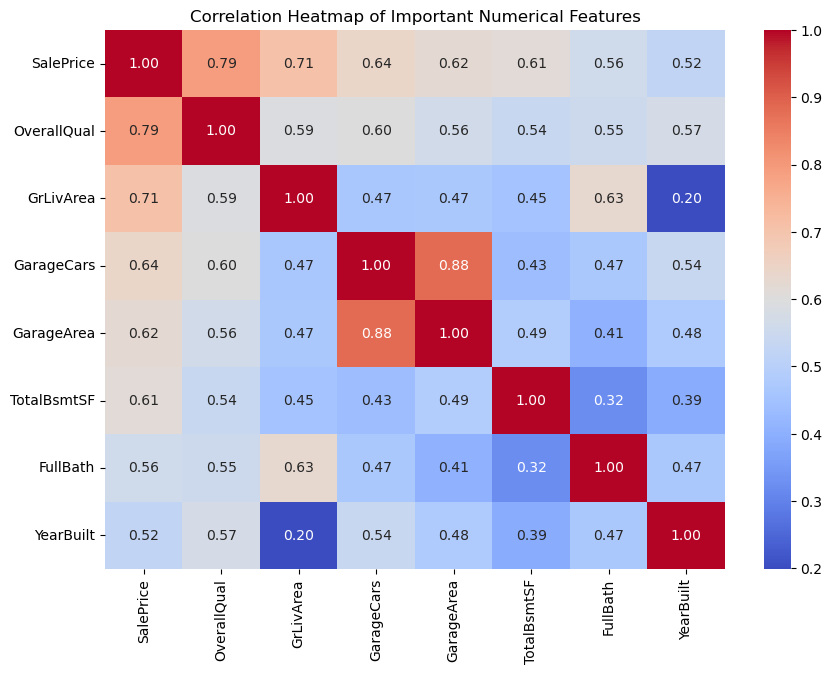

In [26]:
# Select important numerical columns
selected_cols = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[selected_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Important Numerical Features")
plt.show()

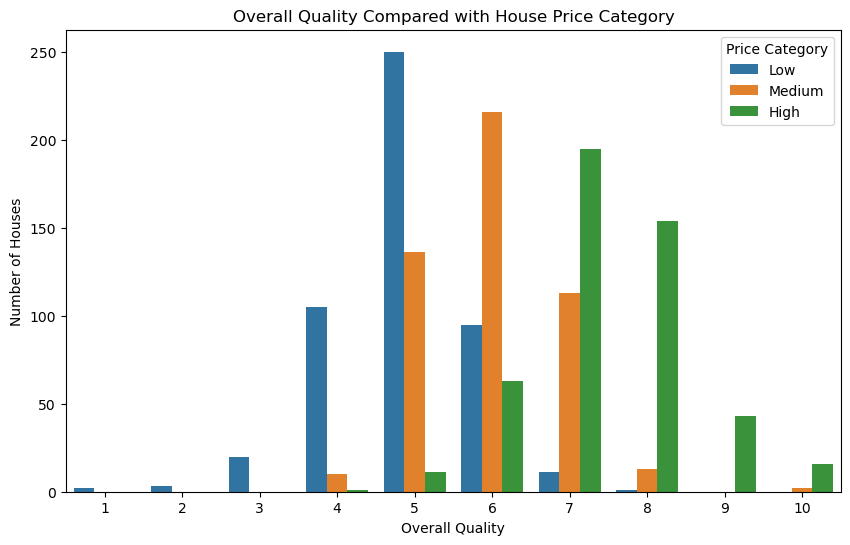

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x="OverallQual",
    hue="PriceCategory",
    data=df,
    hue_order=["Low", "Medium", "High"]
)
plt.title("Overall Quality Compared with House Price Category")
plt.xlabel("Overall Quality")
plt.ylabel("Number of Houses")
plt.legend(title="Price Category")
plt.show()

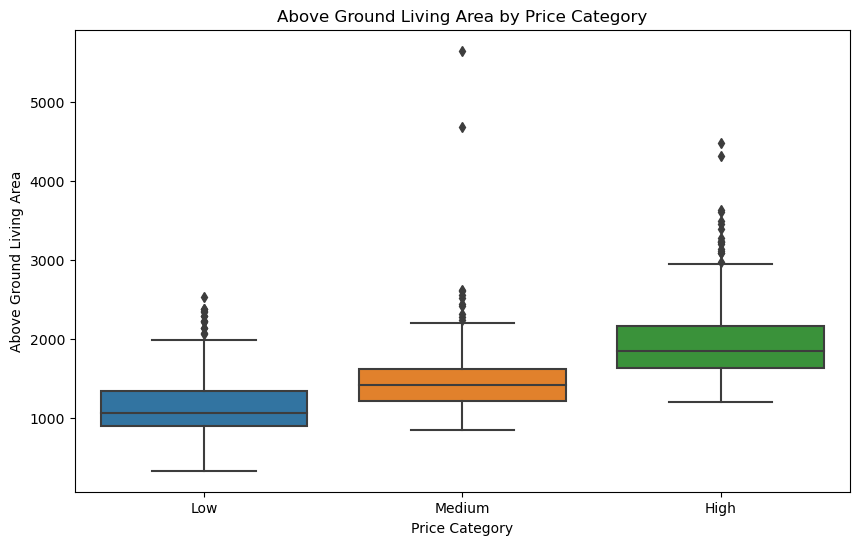

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="PriceCategory",
    y="GrLivArea",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("Above Ground Living Area by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Above Ground Living Area")
plt.show()

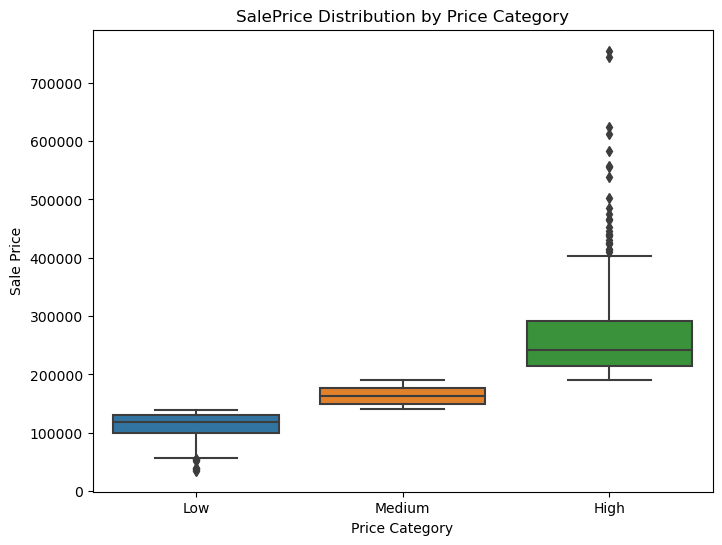

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    x="PriceCategory",
    y="SalePrice",
    data=df,
    order=["Low", "Medium", "High"]
)
plt.title("SalePrice Distribution by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Sale Price")
plt.show()